In [1]:
# restart kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

import math, random, pickle, os, copy, itertools, sys, gpytorch
import torch, logging, scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import random
from datetime import datetime

import matplotlib.pyplot as plt
from collections.abc import Iterable
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device
from utils.utils_pv import visualize_env
from utils.analyze_results import *
from utils.assistive_functions import load_trained_models, softplus_inverse
from utils.pf_scheduler import PriorFactorScheduler
from utils.train_models import train_models

random_seed = 3
random.seed(random_seed)
np.random.seed(random_seed)
random_state = np.random.RandomState(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')
#import platform
#platform.platform()

[WARN] running on CPU


In [2]:
exp_name = 'PV_BiModal'         # PV_BiModal, PV_UniModal_augmented', PV_UniModal
ts_data=False


# Load data
* vary the tilt of the installation and the azimuthal orientation
* same coordinates and altitude of central Lausanne

In [3]:
# ------ LOAD DATA ------
# NOTE: env generated in notebook 1_visualization
filename_env = config.PVDATA_DIR + '/'+ exp_name+"_env"
file = open(filename_env, 'rb')
env_dict = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict['num_clients'])
print(msg)
file.close()
num_clients = env_dict['num_clients'] 
print('\n'+env_dict['info'])

# ----- SELECT A SUBSET OF CLIENTS -----
clients_subset= [12, 14, 15, 17, 22]
print('Subset of clients for demonstration: ', clients_subset)

num_features = len(env_dict['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict['feature_names'])), *env_dict['feature_names'])
    

[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
Subset of clients for demonstration:  [12, 14, 15, 17, 22]

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


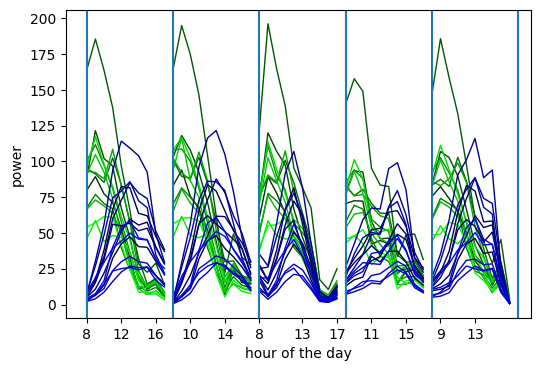

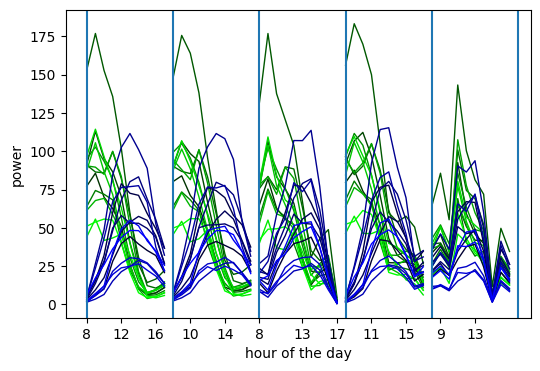

In [4]:
import matplotlib
def visualize_env(env_dict, num_days=5, year=2018, scenario_name=None, figsize=None, fontsize=None):
    ''' visualizes data from the given year '''
    matplotlib.rcParams.update({'font.size': 10 if fontsize is None else fontsize})
    # get data tuples and tie series corresponding to the given scenario
    if scenario_name is None:
        scenario_name = list(env_dict['train_scenarios'].keys())[0]
    clients_data = env_dict['train_scenarios'][scenario_name]['clients_data']
    time_series = env_dict['train_scenarios'][scenario_name]['time_series']

    labels = [int(x) for x in env_dict['clients_config']['azimuth']]
    if len(env_dict['city_names'])==1:
        colors = ["#%06x" % np.random.randint(0, 0xFFFFFF) for _ in range(env_dict['num_clients'])]
    else:
        colors =  [(0,1,0), (0,0,1), (1,0,1)]#list(itertools.product((0,1), (0,1), (0,1)))[1:-1]
        #np.random.shuffle(colors)

    # plot num_days days in the given year
    for month in env_dict['months']:
        client_num = 0
        _, axs = plt.subplots(1, 1, figsize=(30, 8*2) if figsize is None else figsize)
        for mode_num in np.arange(len(env_dict['city_names'])):
            for i in np.arange(env_dict['num_clients_per_mode'][mode_num]):
                # choose color
                if len(env_dict['city_names'])==1:
                    color = colors[client_num]
                else:
                    intensity = 0.2+(1-0.2)*i/(env_dict['num_clients_per_mode'][mode_num]-1) if env_dict['num_clients_per_mode'][mode_num]>1 else 0.5
                    color = tuple(x * intensity for x in colors[mode_num])

                _, y_train, _, y_valid = clients_data[client_num]
                y_mean, y_std = np.mean(y_train, axis=0), np.std(y_train, axis=0) + 1e-8

                # normalized and unnormalized data
                ts_unnorm = time_series[client_num]
                ts_unnorm = ts_unnorm.loc[(ts_unnorm['month']==month) & (ts_unnorm['year']==year), :]
                ts_unnorm = ts_unnorm.loc[ts_unnorm['hour_day'].isin(env_dict['hours']), :]
                ts_unnorm = ts_unnorm.iloc[np.arange(num_days*len(env_dict['hours'])), :]
                ts_norm = (ts_unnorm.loc[:, 'target'] - y_mean) / y_std

                #if mode_num>-1:
                for day_num in np.arange(num_days):
                    inds_day = day_num*len(env_dict['hours']) + np.arange(len(env_dict['hours']))
                    if day_num==0:
                        axs.plot(inds_day, ts_unnorm.loc[:, 'target'].iloc[inds_day],
                                    label=labels[client_num], lw=1, c=color)
                        
                    else:
                        axs.plot(inds_day, ts_unnorm.loc[:, 'target'].iloc[inds_day],
                                    lw=1, c=color)
                        

                client_num += 1
        axs.set_ylabel('power')
 
        #ax.set_title(env_dict['info'] + ' - month ' + str(month))
        for i in np.arange(num_days+1):
            axs.axvline(x=len(env_dict['hours'])*i, ymin=0, ymax=1)
        tick_locs = np.linspace(0, num_days*len(env_dict['hours']),
                                num=int(num_days*len(env_dict['hours'])/4),
                                endpoint=False).astype(int)
        axs.set_xticks(tick_locs, labels=ts_unnorm.loc[:, 'hour_day'].iloc[tick_locs])
        axs.set_xlabel('hour of the day')
        # axs.set_xlabel(str(num_days) + ' days of data')
            #ax.legend(title='azimuth')
        plt.show()


visualize_env(env_dict, num_days=5, year=2018, scenario_name='1y', figsize=(6,4))

# Step 1: load models

In [5]:
# ---------- Load Trained Models ----------
filename_res = os.path.join(os.getcwd(), "saved_results", exp_name)

print('----- loading MAML models -----')
file = open(os.path.join(filename_res, 'MAML', 'MAML'), 'rb')
res = pickle.load(file)
file.close()
results_MAML_new = res['results_new']
results_MAML = res['results']
models_MAML = res['models']

print('----- loading MTL models -----')
file = open(os.path.join(filename_res, 'MTL', 'MTL'), 'rb')
res = pickle.load(file)
file.close()
results_MTL_new = res['results_new']
results_MTL = res['results']
models_MTL = res['models']

print('----- loading our models -----')
models_ours_1y, results_ours_1y = load_trained_models(
    mode='ours', ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'ours_1y'))
models_ours_sml, results_ours_sml = load_trained_models(
    mode='ours', ts_data=ts_data, 
    filename_res=os.path.join(filename_res, 'ours_sml'))

# personal models with reg 
# print('\n\n----- loading individual house models -----')
# models_indiv, results_indiv = load_trained_models(
#     mode='personal', clients_subset=np.arange(num_clients),
#     ts_data=ts_data,
#     filename_res=os.path.join(filename_res, 'personal'))

# shared_nn models
print('\n\n----- loading shared (shared_nn) models -----')
models_shared_nn_1y, results_shared_nn_1y = load_trained_models(
    mode='ours', ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'global_1y'))   
models_shared_nn_sml, results_shared_nn_sml = load_trained_models(
    mode='ours', ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'global_sml'))   


# load pFedGP
print('\n\n----- loading pFedGP and vanilla models -----')
clients_train_data = []
for d in env_dict['train_scenarios']['1y']['clients_data']:
    clients_train_data.append((d[0], d[1]))
models_pFedGP_1y, results_pFedGP_1y = load_trained_models(
    mode='meta_fedavg', methods=None, ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'meta_fedavg_1y'),
    clients_train_data=clients_train_data)
models_vanilla_1y, results_vanilla_1y = load_trained_models(
    mode='vanilla', clients_subset=np.arange(num_clients),
    ts_data=ts_data, clients_train_data=clients_train_data,
    filename_res=os.path.join(filename_res, 'vanilla_1y'))

clients_train_data = []
for d in env_dict['train_scenarios']['sml']['clients_data']:
    clients_train_data.append((d[0], d[1]))
models_pFedGP_sml, results_pFedGP_sml = load_trained_models(
    mode='meta_fedavg', methods=None, ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'meta_fedavg_sml'),
    clients_train_data=clients_train_data)
models_vanilla_sml, results_vanilla_sml = load_trained_models(
    mode='vanilla', clients_subset=np.arange(num_clients),
    ts_data=ts_data, clients_train_data=clients_train_data,
    filename_res=os.path.join(filename_res, 'vanilla_sml'))

----- loading MAML models -----
----- loading MTL models -----
----- loading our models -----

[INFO] results of method nn32_nn4444 loaded.

[INFO] results of method resgp_nn32_nn16 loaded.

[INFO] results of method resgp_nn32_nn16_fixnoise2 loaded.

[INFO] results of method resgp_nn32_nn16_fixnoise6 loaded.

[INFO] results of method resgp_nn32_nn4444 loaded.

[INFO] results of method lingp_nn32 loaded.

[INFO] results of method nn32_nn32 loaded.

[INFO] results of method resgp_nn32_nn64 loaded.

[INFO] results of method resgp_lingp_nn44 loaded.

[INFO] results of method nn32_nn16 loaded.

[INFO] results of method resgp_nn32_nn16_fixnoise4 loaded.

[INFO] results of method resgp_nn32_nn44 loaded.

[INFO] results of method lingp_nn4444 loaded.

[INFO] results of method nn32_nn44 loaded.

[INFO] results of method resgp_nn32_nn16x4 loaded.

[INFO] results of method resgp_nn16x4_nn16 loaded.

[INFO] results of method resgp_nn16x4_nn16_fixnoise2 loaded.

[INFO] results of method resgp_nn32_

In [6]:
models_ours = dict.fromkeys(list(models_ours_1y.keys()) + list(models_ours_sml.keys()))
results_ours = dict.fromkeys(models_ours.keys())
for key in models_ours.keys():
    models_ours[key] = {'sml': None, '1y':None}
    results_ours[key] = {'sml': None, '1y':None}
    if key in models_ours_sml.keys():
        models_ours[key]['sml'] = models_ours_sml[key]['sml']
        results_ours[key]['sml'] = results_ours_sml[key]['sml']
    if key in models_ours_1y.keys():
        models_ours[key]['1y'] = models_ours_1y[key]['1y']
        results_ours[key]['1y'] = results_ours_1y[key]['1y']

models_shared_nn = dict.fromkeys(list(models_shared_nn_1y.keys()) + list(models_shared_nn_sml.keys()))
results_shared_nn = dict.fromkeys(models_shared_nn.keys())
for key in models_shared_nn.keys():
    models_shared_nn[key] = {'sml': None, '1y':None}
    results_shared_nn[key] = {'sml': None, '1y':None}
    if key in models_shared_nn_sml.keys():
        models_shared_nn[key]['sml'] = models_shared_nn_sml[key]['sml']
        results_shared_nn[key]['sml'] = results_shared_nn_sml[key]['sml']
    if key in models_shared_nn_1y.keys():
        models_shared_nn[key]['1y'] = models_shared_nn_1y[key]['1y']
        results_shared_nn[key]['1y'] = results_shared_nn_1y[key]['1y']

models_pFedGP = dict.fromkeys(list(models_pFedGP_1y.keys()) + list(models_pFedGP_sml.keys()))
results_pFedGP = dict.fromkeys(models_pFedGP.keys())
for key in models_pFedGP.keys():
    models_pFedGP[key] = {'sml': None, '1y':None}
    results_pFedGP[key] = {'sml': None, '1y':None}
    if key in models_pFedGP_sml.keys():
        models_pFedGP[key]['sml'] = models_pFedGP_sml[key]['sml']
        results_pFedGP[key]['sml'] = results_pFedGP_sml[key]['sml']
    if key in models_pFedGP_1y.keys():
        models_pFedGP[key]['1y'] = models_pFedGP_1y[key]['1y']
        results_pFedGP[key]['1y'] = results_pFedGP_1y[key]['1y']

models_vanilla = dict.fromkeys(list(models_vanilla_1y.keys()) + list(models_vanilla_sml.keys()))
results_vanilla = dict.fromkeys(models_vanilla.keys())
for key in models_vanilla.keys():
    models_vanilla[key] = {'sml': None, '1y':None}
    results_vanilla[key] = {'sml': None, '1y':None}
    if key in models_vanilla_sml.keys():
        models_vanilla[key]['sml'] = models_vanilla_sml[key]['sml']
        results_vanilla[key]['sml'] = results_vanilla_sml[key]['sml']
    if key in models_vanilla_1y.keys():
        models_vanilla[key]['1y'] = models_vanilla_1y[key]['1y']
        results_vanilla[key]['1y'] = results_vanilla_1y[key]['1y']


# 2. Merge res GP mean and cov

In [7]:
models_resgp = {key:value for key,value in models_ours.items() if 'resgp' in key}
results_resgp = {key:value for key,value in results_ours.items() if 'resgp' in key}
models_ours = {key:value for key,value in models_ours.items() if not 'resgp' in key}
results_ours = {key:value for key,value in results_ours.items() if not 'resgp' in key}


In [8]:
# combine with mean nn
results_PACPFL = copy.deepcopy(results_resgp)
models_PACPFL = models_resgp
for met in results_resgp.keys():
    if results_resgp[met] is None:
        continue
    # set rsmse
    for train_scenario in results_PACPFL[met].keys():
        if results_resgp[met][train_scenario] is None:
            continue
        for valid_or_train in results_resgp[met][train_scenario]['rsmse'].keys():
            if valid_or_train.startswith('criterion'):
                arr1 = np.array(results_resgp[met][train_scenario]['rsmse'][valid_or_train])
                arr2 = np.array(results_shared_nn[met.split('_')[1]][train_scenario]['rsmse'][valid_or_train])
                results_PACPFL[met][train_scenario]['rsmse'][valid_or_train] = arr1 * arr2
                #results_PACPFL[met][train_scenario]['calibr'][valid_or_train] = results_resgp[met][train_scenario]['calibr'][valid_or_train]
        # TODO: how to combine other metrics?


# 3. Compare RSMSE

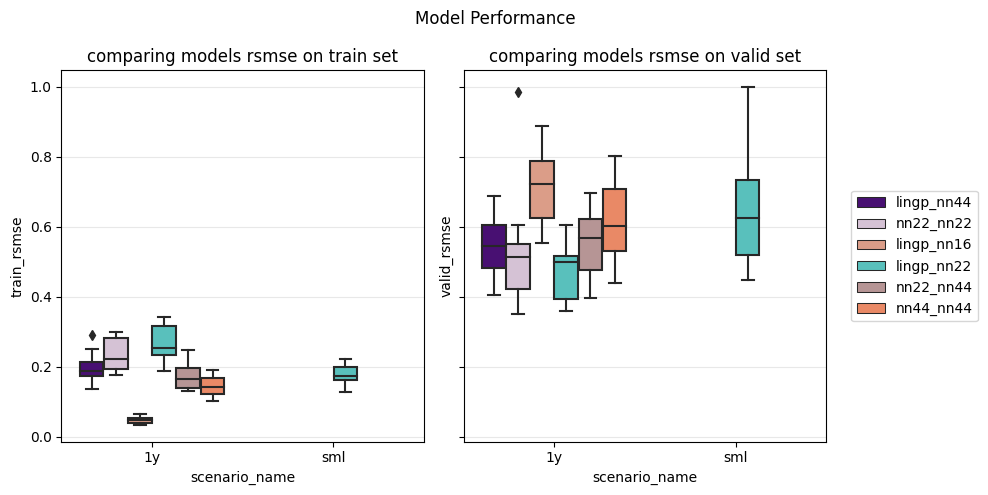

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,lingp_nn16,1y,0.711802,0.552440,0.889227,0.722569
1,lingp_nn22,1y,0.465930,0.359616,0.603991,0.499373
2,lingp_nn22,sml,0.640316,0.449019,0.998663,0.624845
3,lingp_nn44,1y,0.546051,0.405420,0.686663,0.546188
4,nn22_nn22,1y,0.507204,0.350357,0.985525,0.513661
5,nn22_nn44,1y,0.547869,0.396267,0.695568,0.567271
6,nn44_nn44,1y,0.616009,0.440028,0.801962,0.602602


In [9]:
# perf_box_plots(env_dict, criterion='rsmse', results_all=results_indiv, methods=results_indiv.keys())
perf_box_plots(env_dict, criterion='rsmse', results_all=results_vanilla, methods=results_vanilla.keys())


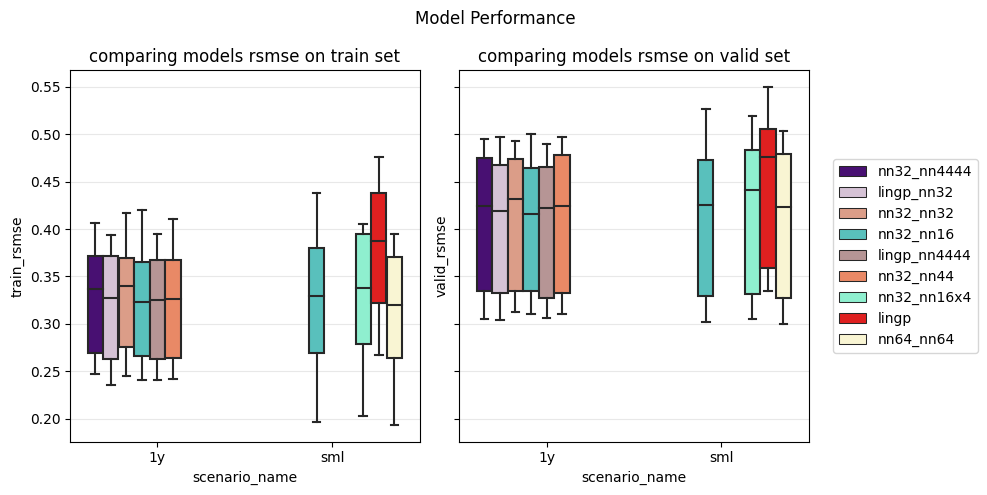

         method scenario_name  valid_rsmse_mean  valid_rsmse_min  \
0         lingp           sml          0.444091         0.334534   
1    lingp_nn32            1y          0.402532         0.304472   
2  lingp_nn4444            1y          0.400938         0.305897   
3     nn32_nn16            1y          0.402264         0.310842   
4     nn32_nn16           sml          0.407673         0.301714   
5   nn32_nn16x4           sml          0.414264         0.305422   
6     nn32_nn32            1y          0.406453         0.312972   
7     nn32_nn44            1y          0.406165         0.310625   
8   nn32_nn4444            1y          0.405325         0.305049   
9     nn64_nn64           sml          0.407359         0.300300   

   valid_rsmse_max  valid_rsmse_median  
0         0.549653            0.476194  
1         0.496685            0.419376  
2         0.489365            0.422628  
3         0.500098            0.415393  
4         0.526744            0.425689  
5    

In [10]:
if len(results_ours.keys())>0:
    stats_df = perf_box_plots(env_dict, criterion='rsmse', results_all=results_ours, methods=results_ours.keys())
    print(stats_df)

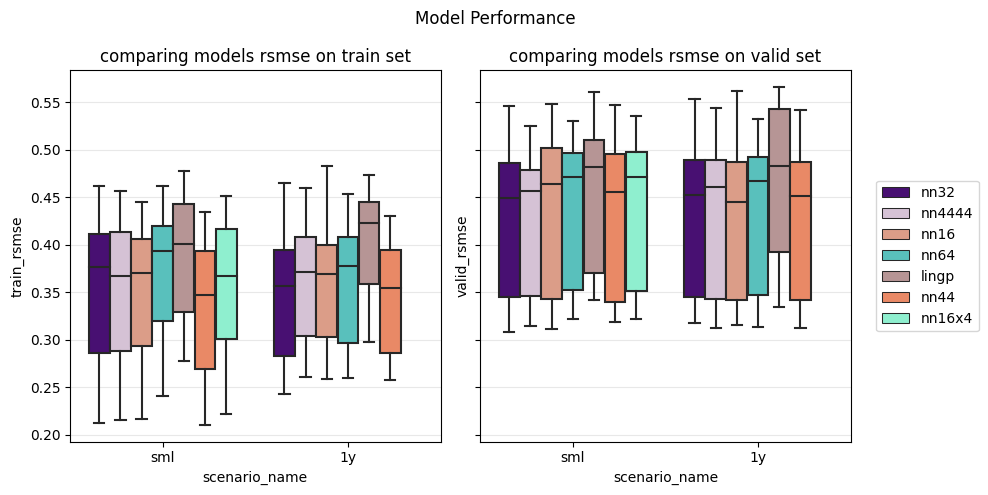

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,lingp,1y,0.465113,0.334496,0.565654,0.482695
1,lingp,sml,0.450580,0.341841,0.560581,0.481272
2,nn16,1y,0.427344,0.315055,0.561999,0.445307
3,nn16,sml,0.429501,0.311006,0.548276,0.464022
4,nn16x4,sml,0.431594,0.321580,0.535719,0.471528
5,nn32,1y,0.426057,0.317764,0.552916,0.452032
6,nn32,sml,0.424642,0.308638,0.546184,0.449284
7,nn44,1y,0.423915,0.312910,0.542129,0.451390
8,nn44,sml,0.427413,0.318484,0.547144,0.455269
9,nn4444,1y,0.431462,0.312322,0.543363,0.460200


In [11]:
if 'nn16_nonar' in results_shared_nn.keys():
    results_shared_nn.pop('nn16_nonar')
perf_box_plots(env_dict, criterion='rsmse', results_all=results_shared_nn, methods=results_shared_nn.keys())

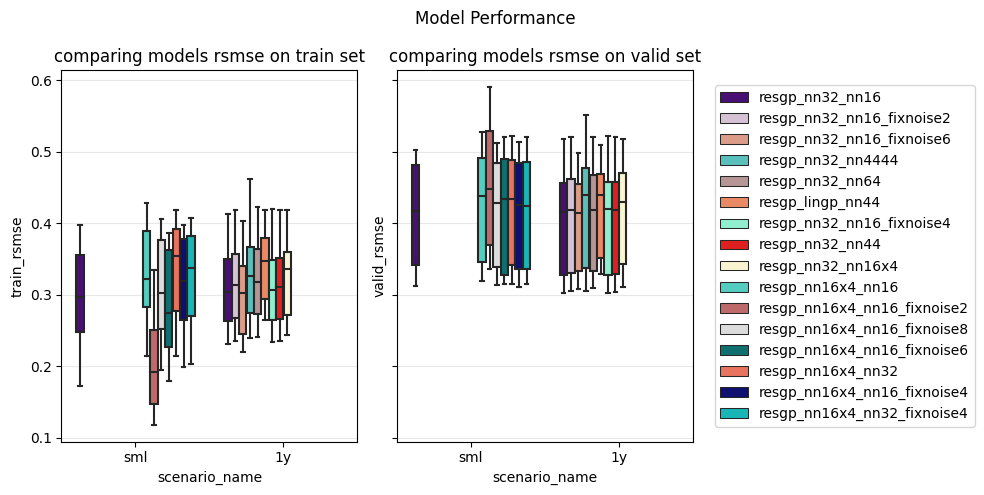

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,resgp_lingp_nn44,1y,0.416558,0.328432,0.509166,0.439995
1,resgp_nn16x4_nn16,sml,0.421287,0.318468,0.527847,0.438014
2,resgp_nn16x4_nn16_fixnoise2,sml,0.449683,0.336459,0.590258,0.447983
3,resgp_nn16x4_nn16_fixnoise4,sml,0.415434,0.310153,0.513207,0.425285
4,resgp_nn16x4_nn16_fixnoise6,sml,0.416605,0.314619,0.519996,0.434259
5,resgp_nn16x4_nn16_fixnoise8,sml,0.416614,0.313319,0.511554,0.428644
6,resgp_nn16x4_nn32,sml,0.418663,0.315129,0.521606,0.433559
7,resgp_nn16x4_nn32_fixnoise4,sml,0.414832,0.315434,0.520041,0.424703
8,resgp_nn32_nn16,1y,0.403107,0.301863,0.517842,0.415985
9,resgp_nn32_nn16,sml,0.411931,0.311637,0.501775,0.416572


In [12]:
perf_box_plots(env_dict, criterion='rsmse', results_all=results_PACPFL, methods=results_PACPFL.keys())

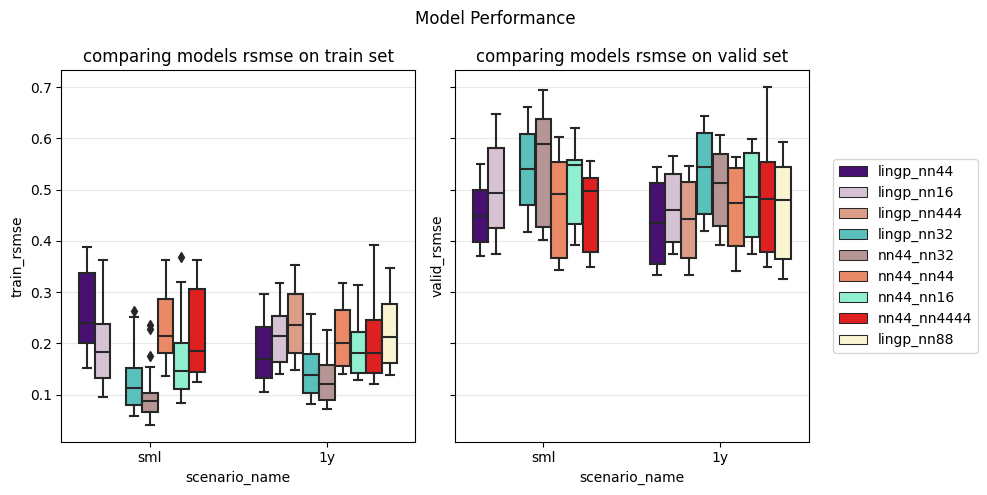

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,lingp_nn16,1y,0.466534,0.375188,0.565409,0.460544
1,lingp_nn16,sml,0.499841,0.373960,0.647914,0.493231
2,lingp_nn32,1y,0.534172,0.419858,0.643081,0.544133
3,lingp_nn32,sml,0.538780,0.416465,0.660912,0.540002
4,lingp_nn44,1y,0.435604,0.334254,0.544756,0.435109
5,lingp_nn44,sml,0.449320,0.369942,0.550598,0.448947
6,lingp_nn444,1y,0.441638,0.332896,0.545915,0.442769
7,lingp_nn88,1y,0.459931,0.325224,0.592289,0.480317
8,nn44_nn16,1y,0.486078,0.375233,0.598168,0.485600
9,nn44_nn16,sml,0.504790,0.390939,0.620318,0.547917


In [13]:
perf_box_plots(env_dict, criterion='rsmse', results_all=results_pFedGP, methods=results_pFedGP.keys())

nn4x4 nn32x2


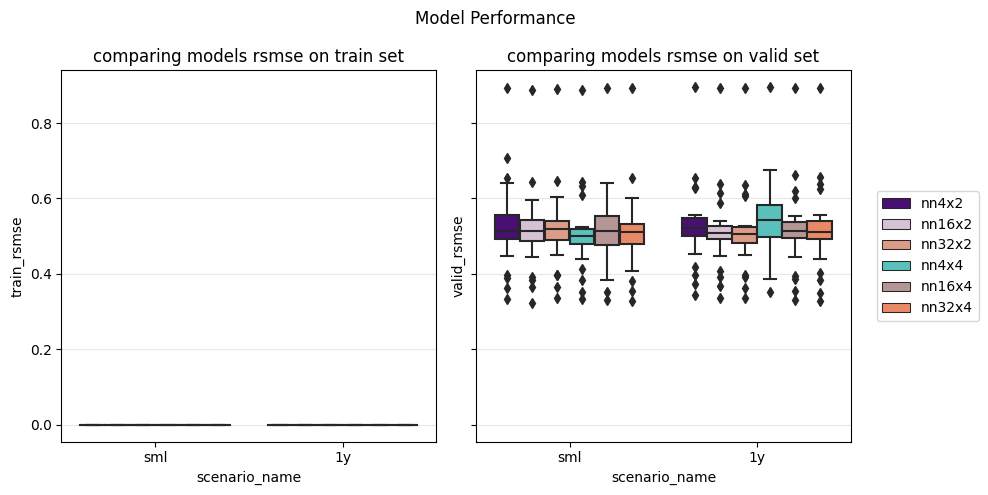

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,nn16x2,1y,0.515740,0.337350,0.892003,0.509508
1,nn16x2,sml,0.515994,0.322967,0.888406,0.512483
2,nn16x4,1y,0.518138,0.329953,0.892860,0.513297
3,nn16x4,sml,0.519329,0.330042,0.891929,0.513818
4,nn32x2,1y,0.512172,0.336478,0.893928,0.504477
5,nn32x2,sml,0.519300,0.335864,0.891137,0.517872
6,nn32x4,1y,0.518359,0.328613,0.892048,0.511841
7,nn32x4,sml,0.512666,0.327854,0.892436,0.511941
8,nn4x2,1y,0.527455,0.344699,0.895128,0.521047
9,nn4x2,sml,0.526409,0.333428,0.894129,0.514114


In [14]:
# put in standard form
for met in results_MAML.keys():
    if results_MAML[met] is None:
        continue
    for scen in results_MAML[met].keys():
        if results_MAML[met][scen] is None:
            continue
        for crit in results_MAML[met][scen].keys():
            if isinstance(results_MAML[met][scen][crit], dict):
                continue
            results_MAML[met][scen][crit] = {
                'criterion_valid':results_MAML[met][scen][crit],
                'criterion_train':np.zeros(num_clients), 'setup':None
            }

# find the best
tmp = 1000
for key in results_MAML.keys():
    if results_MAML[key]['1y'] is None:
        continue
    if np.mean(results_MAML[key]['1y']['rsmse']['criterion_valid'])<=tmp:
        tmp = np.mean(results_MAML[key]['1y']['rsmse']['criterion_valid'])
        best_met_MAML_1y = key
tmp = 1e6
for key in results_MAML.keys():
    if results_MAML[key]['sml'] is None:
        continue
    if np.mean(results_MAML[key]['sml']['rsmse']['criterion_valid'])<=tmp:
        tmp = np.mean(results_MAML[key]['sml']['rsmse']['criterion_valid'])
        best_met_MAML_sml = key
print(best_met_MAML_sml, best_met_MAML_1y)

perf_box_plots(env_dict, criterion='rsmse', results_all=results_MAML, methods=results_MAML.keys())


# 4. Calibration

[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

resgp_nn32_nn16 sml
resgp_nn32_nn16 1y
resgp_nn32_nn16_fixnoise2 1y
resgp_nn32_nn16_fixnoise6 1y
resgp_nn32_nn4444 1y
resgp_nn32_nn64 1y
resgp_lingp_nn44 1y
resgp_nn32_nn16_fixnoise4 1y
resgp_nn32_nn44 1y
resgp_nn32_nn16x4 1y
resgp_nn16x4_nn16 sml
resgp_nn16x4_nn16_fixnoise2 sml
resgp_nn16x4_nn16_fixnoise8 sml
resgp_nn16x4_nn16_fixnoise6 sml
resgp_nn16x4_nn32 sml
resgp_nn16x4_nn16_fixnoise4 sml
resgp_nn16x4_nn32_fixnoise4 sml


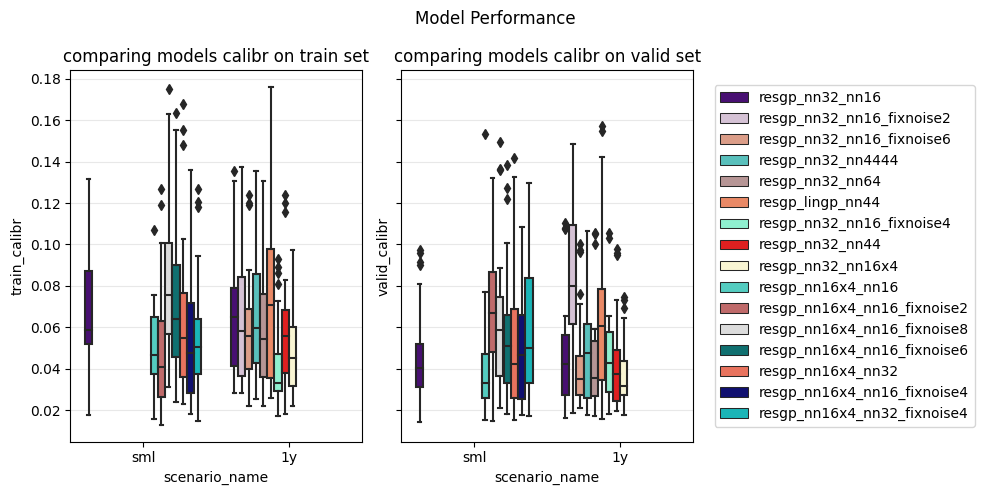

,method,scenario_name,valid_calibr_mean,valid_calibr_min,valid_calibr_max,valid_calibr_median
0,resgp_lingp_nn44,1y,0.064170,0.015619,0.157267,0.060589
1,resgp_nn16x4_nn16,sml,0.041478,0.015414,0.153508,0.033258
2,resgp_nn16x4_nn16_fixnoise2,sml,0.066330,0.014891,0.132139,0.066944
3,resgp_nn16x4_nn16_fixnoise4,sml,0.052345,0.017651,0.108490,0.046478
4,resgp_nn16x4_nn16_fixnoise6,sml,0.058161,0.018215,0.138496,0.051087
5,resgp_nn16x4_nn16_fixnoise8,sml,0.064301,0.020975,0.149322,0.058788
6,resgp_nn16x4_nn32,sml,0.054425,0.015018,0.141666,0.042316
7,resgp_nn16x4_nn32_fixnoise4,sml,0.057890,0.017047,0.129869,0.050239
8,resgp_nn32_nn16,1y,0.047764,0.016034,0.110158,0.042502
9,resgp_nn32_nn16,sml,0.046835,0.014060,0.097227,0.040499


In [15]:
# --- calibration ---
for met in results_resgp.keys():
    if results_resgp[met] is None:
        continue
    for scen in results_resgp[met].keys():
        if results_resgp[met][scen] is None:
            continue

        # 1. select mean model
        mean_method = met.split('_')[1]
        model_mean = models_shared_nn[mean_method][scen]['rsmse']

        # 2. calculate env_dict_res
        env_dict_res = copy.deepcopy(env_dict)
        del env_dict_res['train_scenarios'][scen]['time_series']
        res_train_std, res_valid_std = np.zeros(num_clients), np.zeros(num_clients)
        res_train_mean, res_valid_mean = np.zeros(num_clients), np.zeros(num_clients)
        for client_num in np.arange(num_clients):
            x_train, y_train, x_valid, y_valid = env_dict['train_scenarios'][scen]['clients_data'][client_num]
            # residual of train
            y_train_pred, _ = model_mean.predict(x_train, y_train, x_train)
            y_valid_pred, _ = model_mean.predict(x_train, y_train, x_valid)
            y_train_pred = y_train_pred.reshape(y_train.shape)
            y_valid_pred = y_valid_pred.reshape(y_valid.shape)
            data_tup = (x_train, 
                        y_train-y_train_pred,
                        x_valid,
                        y_valid-y_valid_pred)

            env_dict_res['train_scenarios'][scen]['clients_data'][client_num] = data_tup


        # 3. calibr
        model = models_resgp[met][scen]['rsmse']
        data_tups = env_dict_res['train_scenarios'][scen]['clients_data'] # Note
        # update train
        print(met, scen)
        if met in ['resgp_lingp_nn22', 'resgp_lingp_nn4']:
            continue
        train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
        results_resgp[met][scen]['calibr'] = {
            'criterion_train': model.eval_datasets(train_data, get_full_list=True)['calibr'],
            # update valid
            'criterion_valid': model.eval_datasets(data_tups, get_full_list=True)['calibr']
        }
        results_PACPFL[met][scen]['calibr'] = {
            'criterion_train': model.eval_datasets(train_data, get_full_list=True)['calibr'],
            # update valid
            'criterion_valid': model.eval_datasets(data_tups, get_full_list=True)['calibr']
        }

perf_box_plots(env_dict, criterion='calibr', methods=results_PACPFL.keys(), results_all=results_PACPFL)


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

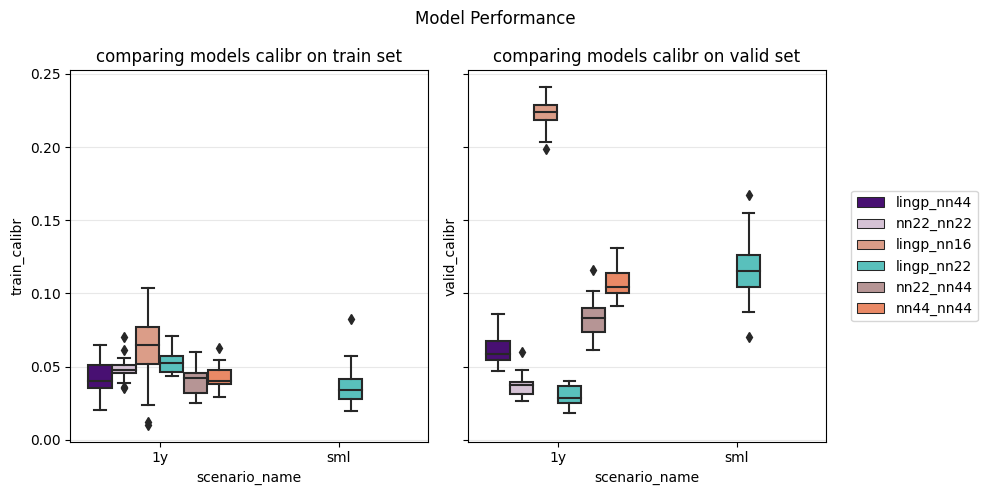

,method,scenario_name,valid_calibr_mean,valid_calibr_min,valid_calibr_max,valid_calibr_median
0,lingp_nn16,1y,0.222287,0.198507,0.240903,0.223652
1,lingp_nn22,1y,0.030134,0.018087,0.040407,0.028593
2,lingp_nn22,sml,0.116224,0.070167,0.167561,0.115254
3,lingp_nn44,1y,0.061727,0.046986,0.086103,0.058724
4,nn22_nn22,1y,0.036432,0.026172,0.059965,0.037173
5,nn22_nn44,1y,0.082802,0.061635,0.115994,0.083321
6,nn44_nn44,1y,0.107041,0.091084,0.131022,0.104595


In [16]:
# compute calibration for each method 
for scen in ['sml', '1y']:
    data_tups = env_dict['train_scenarios'][scen]['clients_data']
    for met in results_vanilla.keys():
        if results_vanilla[met] is None:
            continue
        if results_vanilla[met][scen] is None:
            continue
        results_vanilla[met][scen]['calibr'] = {
            'criterion_train':[None] * num_clients,
            'criterion_valid':[None] * num_clients,
            'setups':[None] * num_clients
        }

        for client_num in np.arange(num_clients):
            train_data = [(data_tups[client_num][0], data_tups[client_num][1], data_tups[client_num][0], data_tups[client_num][1])] 

            # select model with the lowerst RSMSE on the validation set
            model = models_vanilla[met][scen]['rsmse'][client_num]
            if model is None:
                continue
            # update 
            results_vanilla[met][scen]['calibr']['criterion_train'][client_num] = model.eval_datasets(train_data, get_full_list=False)['calibr']
            results_vanilla[met][scen]['calibr']['criterion_valid'][client_num] = model.eval_datasets([data_tups[client_num]], get_full_list=False)['calibr']


perf_box_plots(env_dict, criterion='calibr', results_all=results_vanilla, methods=results_vanilla.keys())

[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

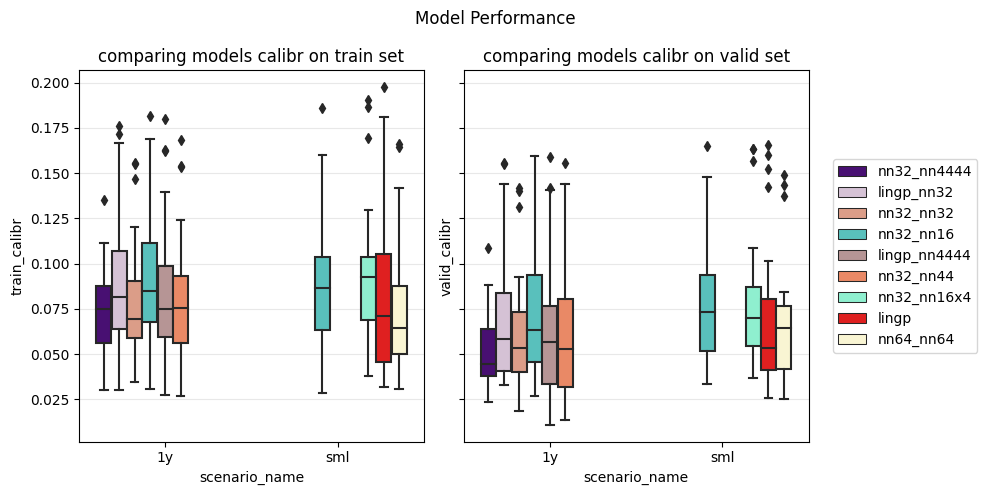

In [17]:
for met in results_ours.keys():
    if results_ours[met] is None:
        continue
    for scen in results_ours[met].keys():
        if models_ours[met][scen] is None:
            continue
        
        # updarw calibration
        model = models_ours[met][scen]['rsmse']
        
        data_tups = env_dict['train_scenarios'][scen]['clients_data']
        # update train
        train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
        results_ours[met][scen]['calibr']['criterion_train'] = model.eval_datasets(train_data, get_full_list=True)['calibr']
        # update valid
        results_ours[met][scen]['calibr']['criterion_valid'] = model.eval_datasets(data_tups, get_full_list=True)['calibr']

if len(results_ours.keys())>0:
    perf_box_plots(env_dict, criterion='calibr', results_all=results_ours, methods=results_ours.keys())

[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

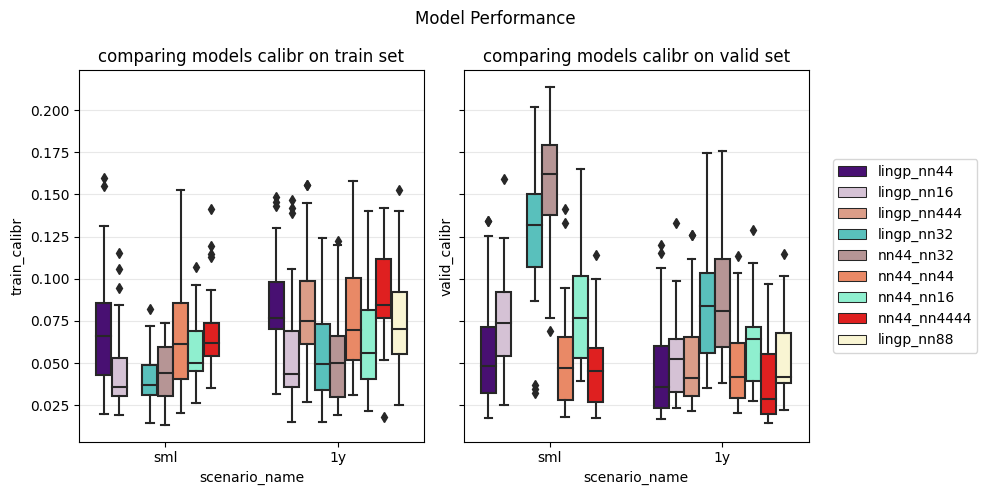

         method scenario_name  valid_calibr_mean  valid_calibr_min  \
0    lingp_nn16            1y           0.057108          0.023725   
1    lingp_nn16           sml           0.074833          0.025220   
2    lingp_nn32            1y           0.084087          0.035011   
3    lingp_nn32           sml           0.124180          0.032082   
4    lingp_nn44            1y           0.047489          0.017137   
5    lingp_nn44           sml           0.058790          0.017255   
6   lingp_nn444            1y           0.053762          0.021624   
7    lingp_nn88            1y           0.053835          0.022053   
8     nn44_nn16            1y           0.060311          0.027880   
9     nn44_nn16           sml           0.081363          0.039375   
10    nn44_nn32            1y           0.086172          0.038508   
11    nn44_nn32           sml           0.154818          0.069248   
12    nn44_nn44            1y           0.050563          0.020279   
13    nn44_nn44     

In [18]:
# calibration of PFedGP
# for each method, select the model with the lowest RSMSE, compute calibr for this model
for met in results_pFedGP.keys():
    if results_pFedGP[met] is None:
        continue
    for scen in ['sml', '1y']:
        if results_pFedGP[met][scen] is None:
            continue
        # update calibration
        model = models_pFedGP[met][scen]['rsmse']
        data_tups = env_dict['train_scenarios'][scen]['clients_data']
        # update train
        train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
        results_pFedGP[met][scen]['calibr']['criterion_train'] = model.eval_datasets(train_data, get_full_list=True)['calibr']
        # update valid
        results_pFedGP[met][scen]['calibr']['criterion_valid'] = model.eval_datasets(data_tups, get_full_list=True)['calibr']
stats_df = perf_box_plots(env_dict, criterion='calibr', results_all=results_pFedGP, methods=results_pFedGP.keys())
print(stats_df)


In [19]:
# get quantiles
# tmp = results_ours_comb['resgp_nn32_nn16']['1y']['rsmse']['criterion_valid']
# print(np.quantile(tmp, 0.25),np.quantile(tmp, 0.5), np.quantile(tmp, 0.75))

# Best Models

In [20]:
if exp_name=='PV_BiModal':    
    best_methods = {
        #'indiv': {'sml':'nn16', '1y':'nn16'},
        'Vanilla': {'sml':'lingp_nn22', '1y':'lingp_nn22'},
        #'ours': {'sml':'nn32_nn16', '1y':'nn32_nn16'},
        'MAML': {'sml':best_met_MAML_sml, '1y':best_met_MAML_1y,},
        'pFedGP': {'sml':'lingp_nn44', '1y':'lingp_nn44'},
        'PAC-PFL': {'sml':'resgp_nn32_nn16', '1y':'resgp_nn32_nn44'}, # {'sml':'resgp_nn16x4_nn16', '1y':'resgp_nn32_nn44'} # 
    }
if exp_name=='PV_UniModal':
    best_methods = {
        'Vanilla': {'sml':'lingp_nn22', '1y':'lingp_nn22'},
        'MAML': {'sml':'nn4x4', '1y':'nn4x4',},
        'pFedGP': {'sml':'lingp_nn44', '1y':'lingp_nn444'},
        'PAC-PFL': {'sml':'resgp_nn4444_nn44fixl', '1y':'resgp_nn44_nn22fixl'}, 
    }


best_res = dict.fromkeys(['Vanilla', 'MAML', 'MTL', 'pFedGP', 'PAC-PFL'])
best_mdl = copy.deepcopy(best_methods)
for key in best_res.keys():
    if key=='MTL':
        continue
    best_res[key] = dict.fromkeys(['sml', '1y'])
    for scen in best_res[key].keys():
        if key=='Vanilla':
             best_res[key][scen] = results_vanilla[best_methods[key][scen]][scen]
             best_mdl[key][scen] = models_vanilla[best_methods[key][scen]][scen]['rsmse']
        # elif key=='indiv':
        #     best_res[key][scen] = results_indiv[best_methods[key][scen]][scen]
        elif key=='ours':
            best_res[key][scen] = results_ours[best_methods[key][scen]][scen]
            best_mdl[key][scen] = models_ours[best_methods[key][scen]][scen]['rsmse']
        elif key=='PAC-PFL':
            best_res[key][scen] = results_PACPFL[best_methods[key][scen]][scen]
            best_mdl[key][scen] = models_PACPFL[best_methods[key][scen]][scen]['rsmse']
        elif key=='pFedGP':
            best_res[key][scen] = results_pFedGP[best_methods[key][scen]][scen]
            best_mdl[key][scen] = models_pFedGP[best_methods[key][scen]][scen]['rsmse']
        elif key=='MAML':
            best_res[key][scen] = results_MAML[best_methods[key][scen]][scen]
            best_mdl[key][scen] = models_MAML[best_methods[key][scen]][scen]
        # only keep criterion_valid 
        print(key, scen)
        # for criterion in best_res[key][scen].keys():
        #     if isinstance(best_res[key][scen][criterion], dict):
        #         print('err', key, criterion)
                # best_res[key][scen][criterion] = best_res[key][scen][criterion]['criterion_valid']


best_res['MTL'] = results_MTL

# perf_box_plots(
#     env_dict, criterion='rsmse', 
#     results_all=best_res, methods=best_res.keys())

Vanilla sml
Vanilla 1y
MAML sml
MAML 1y
pFedGP sml
pFedGP 1y
PAC-PFL sml
PAC-PFL 1y


In [21]:
# perf_box_plots(
#     env_dict, criterion='calibr', 
#     results_all=best_res, methods=['Vanilla', 'pFedGP', 'PAC-PFL'])

# New Clients

In [22]:
exp_name_ptc = exp_name
exp_name_new = exp_name_ptc + '_NewClients'


# ----- SET UP LOGGER -----
filename_env_new = config.PVDATA_DIR + '/'+ exp_name_ptc +"_new_clients_env"
filename_res_new = os.path.join(os.getcwd(), "saved_results", exp_name_new)


# ------ LOAD META_TEST DATA ------
file = open(filename_env_new, 'rb')
env_dict_new = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_new['num_clients'])
print(msg)
file.close()
num_clients_new = env_dict_new['num_clients'] 
print('\n'+env_dict_new['info'])



for scenario_name in env_dict_new['train_scenarios'].keys():
    print(scenario_name + ' has {:3.0f} train and {:3.0f} validation samples'.format(
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][0].shape[0],
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][2].shape[0]))
num_features = len(env_dict_new['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict_new['feature_names'])), *env_dict_new['feature_names'])

# visualize_env(env_dict_new, num_days=5, year=2018, scenario_name='1y')


[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
sml has 150 train and 610 validation samples
1y has 610 train and 610 validation samples
5y has 3050 train and 610 validation samples
14y has 8540 train and 610 validation samples

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


In [23]:
# best on new clients
best_res_new = copy.deepcopy(best_res)
clients_data_new = env_dict_new['train_scenarios']['sml']['clients_data'] # IMPORTANT: small data of new

# --- calibration ---
for scen in ['sml', '1y']:
    met = best_methods['PAC-PFL'][scen]

    # 1. select mean model
    mean_method = met.split('_')[1]
    model_mean = models_shared_nn[mean_method][scen]['rsmse']
    results_mean_new_valid = np.array(model_mean.eval_datasets(clients_data_new, get_full_list=True)['rsmse'])
    
    # 2. calculate env_dict_res
    env_dict_res_new = copy.deepcopy(env_dict_new)
    del env_dict_res_new['train_scenarios'][scen]['time_series']
    # res_train_std, res_valid_std = np.zeros(num_clients_new), np.zeros(num_clients_new)
    # res_train_mean, res_valid_mean = np.zeros(num_clients_new), np.zeros(num_clients_new)
    for client_num in np.arange(num_clients_new):
        x_train, y_train, x_valid, y_valid = env_dict_new['train_scenarios'][scen]['clients_data'][client_num]
        # residual of train
        y_train_pred, _ = model_mean.predict(x_train, y_train, x_train)
        y_valid_pred, _ = model_mean.predict(x_train, y_train, x_valid)
        y_train_pred = y_train_pred.reshape(y_train.shape)
        y_valid_pred = y_valid_pred.reshape(y_valid.shape)
        data_tup = (x_train, 
                    y_train-y_train_pred,
                    x_valid,
                    y_valid-y_valid_pred)
        env_dict_res_new['train_scenarios'][scen]['clients_data'][client_num] = data_tup

    # 3. calibr and RSMSE
    model = models_resgp[met][scen]['rsmse']
    data_tups = env_dict_res_new['train_scenarios'][scen]['clients_data'] # Note
    train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
    res_train = model.eval_datasets(train_data, get_full_list=True)
    res_valid = model.eval_datasets(data_tups, get_full_list=True)
    best_res_new['PAC-PFL'][scen]['calibr'] = np.array(res_valid['calibr'])
    best_res_new['PAC-PFL'][scen]['rsmse'] = np.array(res_valid['rsmse'])*results_mean_new_valid



[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

In [24]:
# all methods on new clients
results_PACPFL_new = copy.deepcopy(results_PACPFL)
clients_data_new = env_dict_new['train_scenarios']['sml']['clients_data'] # IMPORTANT: small data of new


# --- calibration ---
for scen in ['sml', '1y']:
    for met in results_PACPFL_new.keys():
        if models_resgp[met][scen] is None:
            continue
        # 1. select mean model
        mean_method = met.split('_')[1]
        model_mean = models_shared_nn[mean_method][scen]['rsmse']
        results_mean_new_valid = np.array(model_mean.eval_datasets(clients_data_new, get_full_list=True)['rsmse'])
        results_mean_new_train = np.array(model_mean.eval_datasets(
            [(d[0], d[1], d[0], d[1]) for d in clients_data_new], 
            get_full_list=True)['rsmse']
        )

        # 2. calculate env_dict_res
        env_dict_res_new = copy.deepcopy(env_dict_new)
        del env_dict_res_new['train_scenarios'][scen]['time_series']
        # res_train_std, res_valid_std = np.zeros(num_clients_new), np.zeros(num_clients_new)
        # res_train_mean, res_valid_mean = np.zeros(num_clients_new), np.zeros(num_clients_new)
        for client_num in np.arange(num_clients_new):
            x_train, y_train, x_valid, y_valid = env_dict_new['train_scenarios'][scen]['clients_data'][client_num]
            # residual of train
            y_train_pred, _ = model_mean.predict(x_train, y_train, x_train)
            y_valid_pred, _ = model_mean.predict(x_train, y_train, x_valid)
            y_train_pred = y_train_pred.reshape(y_train.shape)
            y_valid_pred = y_valid_pred.reshape(y_valid.shape)
            data_tup = (x_train, 
                        y_train-y_train_pred,
                        x_valid,
                        y_valid-y_valid_pred)
            env_dict_res_new['train_scenarios'][scen]['clients_data'][client_num] = data_tup

        # 3. calibr and RSMSE
        model = models_resgp[met][scen]['rsmse']
        data_tups = env_dict_res_new['train_scenarios'][scen]['clients_data'] # Note
        train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
        res_train = model.eval_datasets(train_data, get_full_list=True)
        res_valid = model.eval_datasets(data_tups, get_full_list=True)
        results_PACPFL_new[met][scen]['calibr'] = {
            'criterion_train': np.array(res_train['calibr']),
            # update valid
            'criterion_valid': np.array(res_valid['calibr'])
        }
 
        results_PACPFL_new[met][scen]['rsmse'] = {
            'criterion_train': np.array(res_train['rsmse'])*results_mean_new_train,
            # update valid
            'criterion_valid': np.array(res_valid['rsmse'])*results_mean_new_valid
        }


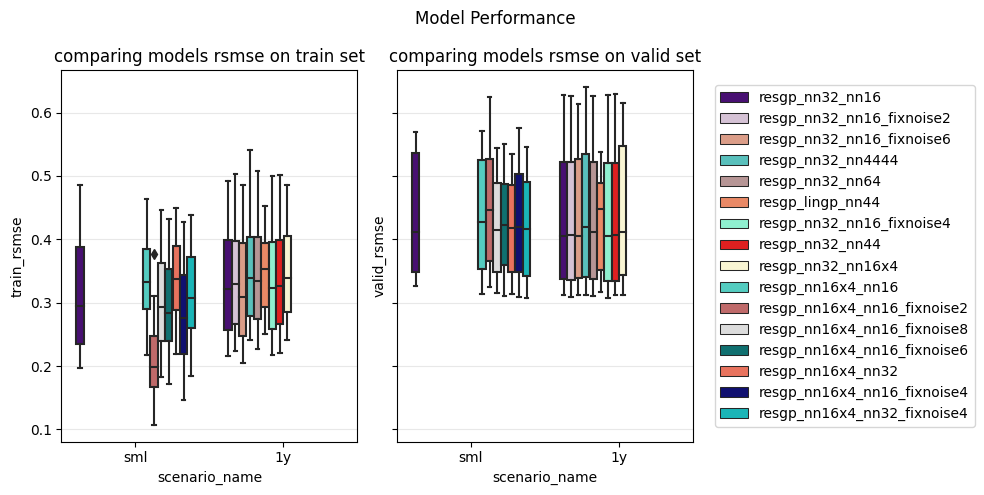

                         method scenario_name  valid_rsmse_mean  \
0              resgp_lingp_nn44            1y          0.423594   
1             resgp_nn16x4_nn16           sml          0.438873   
2   resgp_nn16x4_nn16_fixnoise2           sml          0.448872   
3   resgp_nn16x4_nn16_fixnoise4           sml          0.425479   
4   resgp_nn16x4_nn16_fixnoise6           sml          0.421709   
5   resgp_nn16x4_nn16_fixnoise8           sml          0.418923   
6             resgp_nn16x4_nn32           sml          0.417037   
7   resgp_nn16x4_nn32_fixnoise4           sml          0.417045   
8               resgp_nn32_nn16            1y          0.429872   
9               resgp_nn32_nn16           sml          0.437817   
10    resgp_nn32_nn16_fixnoise2            1y          0.431700   
11    resgp_nn32_nn16_fixnoise4            1y          0.430486   
12    resgp_nn32_nn16_fixnoise6            1y          0.431094   
13            resgp_nn32_nn16x4            1y          0.44431

In [25]:
s= perf_box_plots(
    env_dict_new, criterion='rsmse', 
    results_all=results_PACPFL_new, methods=results_PACPFL_new.keys())
print(s)

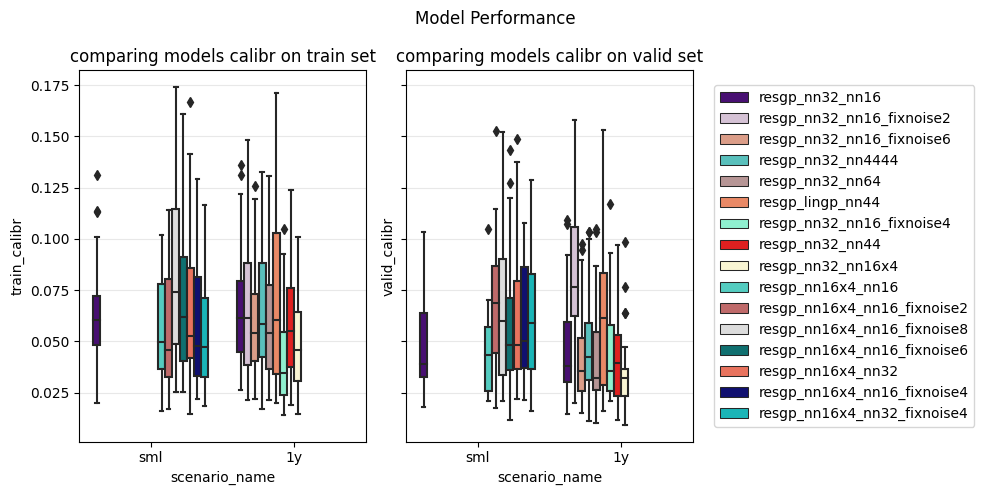

                         method scenario_name  valid_calibr_mean  \
0              resgp_lingp_nn44            1y           0.064375   
1             resgp_nn16x4_nn16           sml           0.043692   
2   resgp_nn16x4_nn16_fixnoise2           sml           0.070488   
3   resgp_nn16x4_nn16_fixnoise4           sml           0.058002   
4   resgp_nn16x4_nn16_fixnoise6           sml           0.059874   
5   resgp_nn16x4_nn16_fixnoise8           sml           0.065926   
6             resgp_nn16x4_nn32           sml           0.060756   
7   resgp_nn16x4_nn32_fixnoise4           sml           0.060116   
8               resgp_nn32_nn16            1y           0.048421   
9               resgp_nn32_nn16           sml           0.050355   
10    resgp_nn32_nn16_fixnoise2            1y           0.080309   
11    resgp_nn32_nn16_fixnoise4            1y           0.044298   
12    resgp_nn32_nn16_fixnoise6            1y           0.043563   
13            resgp_nn32_nn16x4            1y   

In [26]:
s = perf_box_plots(
    env_dict_new, criterion='calibr', 
    results_all=results_PACPFL_new, methods=results_PACPFL_new.keys())
print(s)


In [27]:
mode = 'pFedGP'
for scen in best_res[mode].keys():
    model = best_mdl[mode][scen]
    best_res_new[mode][scen] = model.eval_datasets(clients_data_new, flatten_y=True, get_full_list=True)
    for key in best_res_new[mode][scen].keys():
        best_res_new[mode][scen][key] = np.array(best_res_new[mode][scen][key])


mode = 'Vanilla'
# scenario has no effect in vanilla, b.c. scenario is how other clients were.  
filename_res = os.path.join(os.getcwd(), "saved_results", exp_name+'_NewClients')
models_vanilla_new, results_vanilla_new = load_trained_models(
    mode='vanilla', methods=[best_methods['Vanilla']['sml']+'_new_clients'], ts_data=ts_data,
    filename_res=os.path.join(filename_res, 'vanilla_1y'),
    clients_train_data=[(d[0], d[1]) for d in env_dict_new['train_scenarios']['sml']['clients_data']]
)
r = results_vanilla_new[best_methods['Vanilla']['sml']+'_new_clients']['sml']
for scen in ['sml', '1y']: # has no effect
    for criterion in r.keys():
        best_res_new[mode][scen][criterion] = r[criterion]['criterion_valid'] # IMPORTANT: same for sml and 1y

# MAML
for scen in ['sml', '1y']:
    best_res_new['MAML'][scen] = results_MAML_new[best_methods['MAML'][scen]][scen]

# MTL
for scen in ['sml', '1y']:
    best_res_new['MTL'][scen]['rsmse'] = results_MTL_new[scen]['rsmse']['criterion_valid']



[INFO] results of method lingp_nn22_new_clients loaded.
[INFO] models trained by method lingp_nn22_new_clients in scenario sml loaded.
[INFO] models trained by method lingp_nn22_new_clients in scenario sml loaded.
[INFO] models trained by method lingp_nn22_new_clients in scenario sml loaded.


# Box plot with both calibration and RSMSE

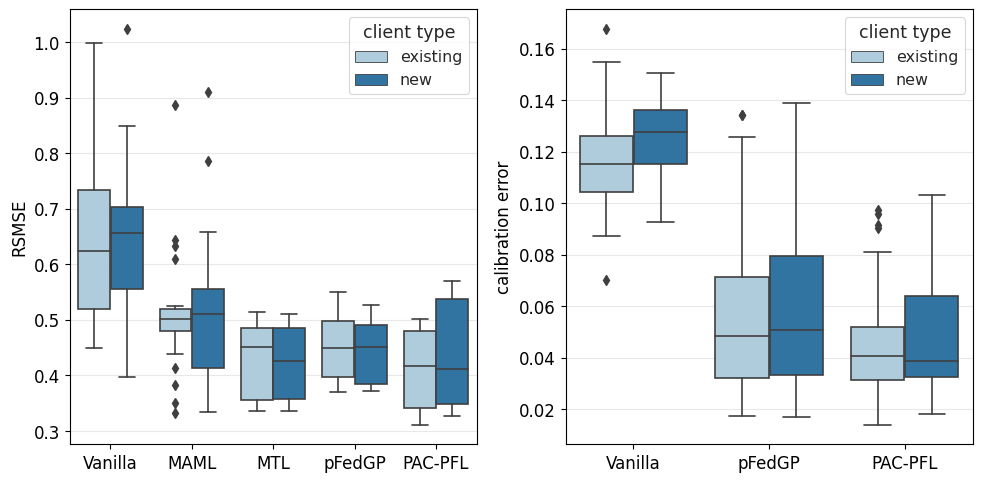

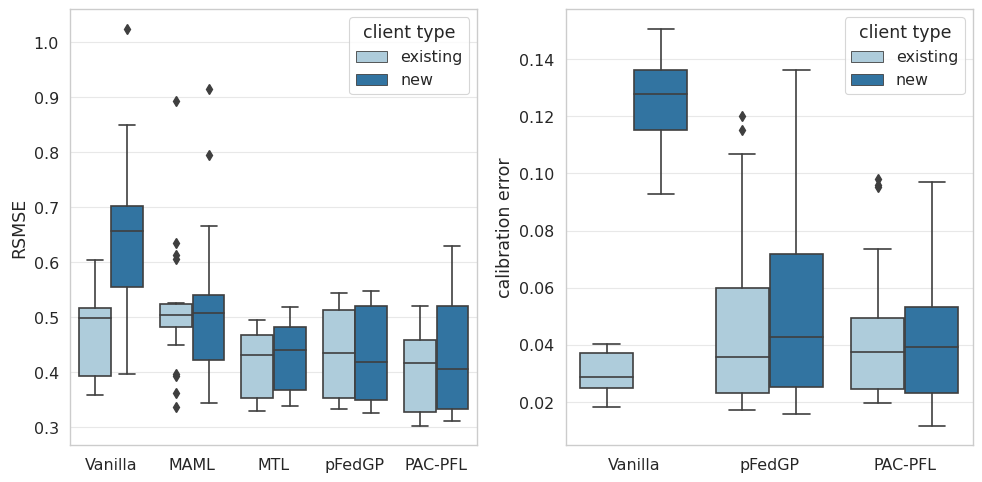

In [28]:
def rsmse_calibr_box_plots(
    env_dict, methods, results_all, results_all_new, scenario_name,
    clients_subset=None, plot_title=None, figsize=(10, 5), num_hyper_params=None, save_fig=False):
    plt.rcParams['font.size'] = '12'
    
    # plt.rcParams['font.family'] = 'DeJavu Serif'
    # plt.rcParams['font.serif'] = ['Times New Roman']
    # plt.rc('xtick', labelsize='x-small')
    # plt.rc('ytick', labelsize='x-small')

    # sort methods by num hyper_params
    if not num_hyper_params is None:
        assert len(num_hyper_params.keys())==len(methods)
        num_hyper_params = dict(sorted(num_hyper_params.items(), key=lambda item: item[1]))
        methods=num_hyper_params.keys()

    num_clients = env_dict['num_clients']
    if clients_subset is None:
        clients_subset = np.arange(num_clients)
    clients_subset_new = np.arange(num_clients_new)
    num_rows = (len(clients_subset)+len(clients_subset_new)) * len(env_dict['train_scenarios']) * len(methods)
    res_df = {'client_num': np.zeros(num_rows), 
            'scenario_name': [None]*num_rows,
            'RSMSE': np.zeros(num_rows),
            'calibration error': np.ones(num_rows),
            'method':[None]*num_rows,
            'client type':[None]*num_rows}
    n=0
    for method in methods:
        if results_all[method] is None:
            print('[WARN] skipped ', method)
            continue
        if not scenario_name in results_all[method].keys():
            print('[WARN] scenario_name not in ', method)
            continue
        if results_all[method][scenario_name] is None:
            print('[WARN] results scenario_name not found for ', method)
            continue
        # existing
        for client_num in clients_subset:
            res_df['client type'][n] = 'existing'
            res_df['client_num'][n] = client_num
            res_df['scenario_name'][n] = scenario_name
            res_df['method'][n] = method if num_hyper_params is None else method + '(' + str(num_hyper_params[method]) + ')'
            res_df['RSMSE'][n] = results_all[method][scenario_name]['rsmse']['criterion_valid'][client_num]
            if 'calibr' in results_all[method][scenario_name].keys():
                r = results_all[method][scenario_name]['calibr']
                if isinstance(r, list):
                    assert len(r)==num_clients
                    res_df['calibration error'][n] = r[client_num]['criterion_valid']
                elif isinstance(r, dict):
                    res_df['calibration error'][n] = r['criterion_valid'][client_num]
            n +=1
        # new
        for client_num in clients_subset_new:
            res_df['client type'][n] = 'new'
            res_df['client_num'][n] = client_num
            res_df['scenario_name'][n] = scenario_name
            res_df['method'][n] = method if num_hyper_params is None else method + '(' + str(num_hyper_params[method]) + ')'
            # if method == 'PAC-PFL':
            #     res_df['method'][n] = '\033[1m' + res_df['method'][n] 
            #     print('\033[1m' + res_df['method'][n])
            a = results_all_new[method][scenario_name]['rsmse'][client_num]
            res_df['RSMSE'][n] = results_all_new[method][scenario_name]['rsmse'][client_num]
            if 'calibr' in results_all_new[method][scenario_name].keys():
                r = results_all_new[method][scenario_name]['calibr']
                if isinstance(r, list) or isinstance(r, np.ndarray):
                    assert len(r)==num_clients
                    res_df['calibration error'][n] = r[client_num]#['criterion_valid']
                elif isinstance(r, dict):
                    res_df['calibration error'][n] = r['criterion_valid'][client_num]
                else:
                    print(type(r))
            n +=1

    res_df = pd.DataFrame(data=res_df)

    # plot
    plot_title = 'Model Performance' if plot_title==None else plot_title
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    fig.subplots_adjust(left=0.075, right=0.95, top=0.9, bottom=0.25)
    random.seed(3)
    colors = random.sample(sorted(mcolors.CSS4_COLORS), len(methods))
    for ax, criterion in zip(axs, ['RSMSE', 'calibration error']):
        # Add a horizontal grid to the plot, but make it very light in color
        # so we can use it for reading data values but not be distracting
        ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey',
                    alpha=0.5)
        ax.set(
            axisbelow=True,  # Hide the grid behind plot objects
            #title='test ' + criterion,
            #xlabel='method',
            ylabel= criterion,
        )

        if criterion=='calibration error':
            res_df = res_df.drop(res_df[res_df['method']=='MAML'].index)
            res_df = res_df.drop(res_df[res_df['method']=='MTL'].index)
        sns.set(style="whitegrid", palette="Paired", color_codes=True)
        sns.set_context("paper", font_scale=1.3)
        g = sns.boxplot(y=criterion, x='method',
                    data=res_df,
                    # palette=colors,
                    hue='client type',
                    ax=ax)
        g.set(xlabel=None)
        # if train_or_valid=='valid':
        #     plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
        # else:
        #     ax.legend([],[], frameon=False)

    # fig.suptitle(plot_title)
    plt.tight_layout()
    if save_fig:
        plt.savefig(scenario_name+".pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # print stats
    # stats_df = res_df.groupby(['method', 'scenario_name']).agg(
    #     {'valid_'+criterion: ['mean', 'min', 'max', 'median']})
    # stats_df.columns = ['valid_'+criterion + '_' + x for x in ['mean', 'min', 'max', 'median']]
    # stats_df = stats_df.reset_index()
    # stats_df.style.highlight_min(color='lightgreen', axis=0)
    return #stats_df
if 'ours' in best_methods.keys():
    best_methods.pop('ours')
# methods_prob = list(best_res.keys())
# methods_prob.remove('MTL')
# methods_prob.remove('MAML')
rsmse_calibr_box_plots(
    env_dict, methods=best_res.keys(), results_all=best_res, results_all_new=best_res_new, scenario_name='sml',
    clients_subset=None, plot_title=None, figsize=(10, 5), num_hyper_params=None)
rsmse_calibr_box_plots(
    env_dict, methods=best_res.keys(), results_all=best_res, results_all_new=best_res_new, scenario_name='1y',
    clients_subset=None, plot_title=None, figsize=(10, 5), num_hyper_params=None)